<h1>House Price Prediction</h1>

<h2>1.IMPORTING LIBRARIES</h2>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from ydata_profiling import ProfileReport
from sklearn.preprocessing import FunctionTransformer,PolynomialFeatures,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV,LinearRegression,LassoCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

C:\Users\Arush Parikh\AppData\Local\Temp\ipykernel_18948\2325415423.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


 <h2>2.LOADING DATASET</h2>

In [2]:
df = pd.read_csv("../DATASET/kc_house_data.csv")
print(df.head())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

<h2>3.UNDERSTANDING THE DATASET</h2>

In [3]:
print(df.columns)
df.shape

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


(21613, 21)

In [4]:
df=df.drop(columns=['id','date','view','condition','grade','zipcode','lat','long','yr_renovated','waterfront'])
print(df.head())

      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  sqft_above  \
0  221900.0         3       1.00         1180      5650     1.0        1180   
1  538000.0         3       2.25         2570      7242     2.0        2170   
2  180000.0         2       1.00          770     10000     1.0         770   
3  604000.0         4       3.00         1960      5000     1.0        1050   
4  510000.0         3       2.00         1680      8080     1.0        1680   

   sqft_basement  yr_built  sqft_living15  sqft_lot15  
0              0      1955           1340        5650  
1            400      1951           1690        7639  
2              0      1933           2720        8062  
3            910      1965           1360        5000  
4              0      1987           1800        7503  


In [5]:
print(df.describe())

              price      bedrooms     bathrooms   sqft_living      sqft_lot  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  2.161300e+04   
mean   5.400881e+05      3.370842      2.114757   2079.899736  1.510697e+04   
std    3.671272e+05      0.930062      0.770163    918.440897  4.142051e+04   
min    7.500000e+04      0.000000      0.000000    290.000000  5.200000e+02   
25%    3.219500e+05      3.000000      1.750000   1427.000000  5.040000e+03   
50%    4.500000e+05      3.000000      2.250000   1910.000000  7.618000e+03   
75%    6.450000e+05      4.000000      2.500000   2550.000000  1.068800e+04   
max    7.700000e+06     33.000000      8.000000  13540.000000  1.651359e+06   

             floors    sqft_above  sqft_basement      yr_built  sqft_living15  \
count  21613.000000  21613.000000   21613.000000  21613.000000   21613.000000   
mean       1.494309   1788.390691     291.509045   1971.005136    1986.552492   
std        0.539989    828.090978     442.575

In [6]:
print(df.isnull().sum())

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
sqft_above       0
sqft_basement    0
yr_built         0
sqft_living15    0
sqft_lot15       0
dtype: int64


<h2>4.EXPLORATORY DATA ANALYSIS</h2>

In [10]:
profile = ProfileReport(df, title="King County Housing Data Profile")
profile.to_file("houseprice.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 999.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
df.drop_duplicates(inplace=True)

<h2>5.OUTLIER DETECTION AND TREATMENT</h2>

In [8]:
%matplotlib inline

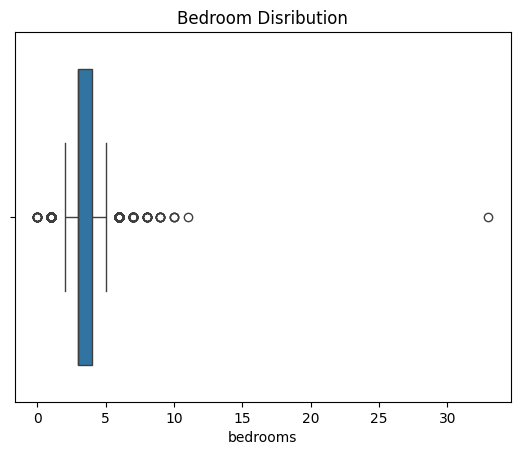

In [9]:
sns.boxplot(x=df['bedrooms'])
plt.title("Bedroom Disribution")
plt.show()

<Axes: xlabel='bedrooms'>

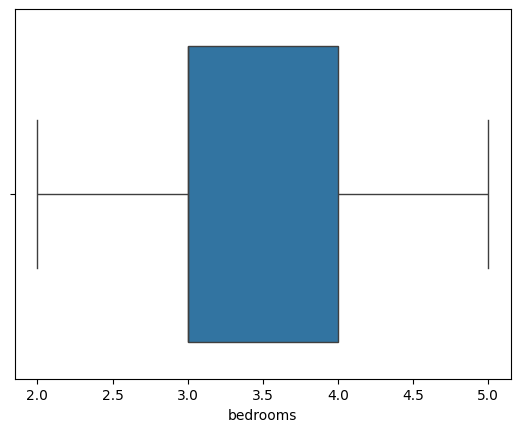

In [10]:
q1=df['bedrooms'].quantile(0.25)
q3=df['bedrooms'].quantile(0.75)
iqr=q3-q1;

lower_range=q1-1.5*iqr;
upper_range=q3+1.5*iqr;

newdf=df[(df['bedrooms']>lower_range) & (df['bedrooms']<upper_range)]
sns.boxplot(x=newdf['bedrooms'])

Text(0.5, 1.0, 'sqft distribution')

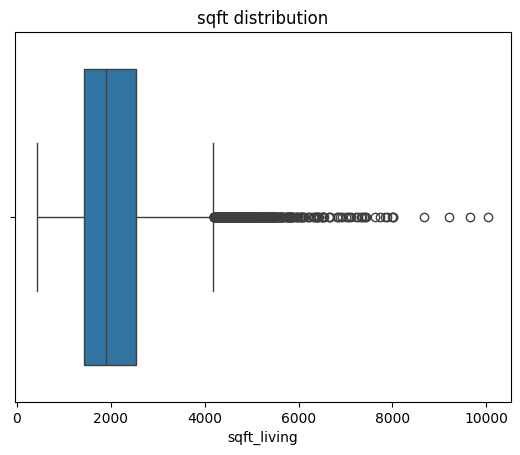

In [11]:
sns.boxplot(x=newdf['sqft_living'])
plt.title("sqft distribution")

In [12]:
print("Before: ",newdf.shape)
newdf=newdf[newdf['sqft_living']<7000]
print("After :",newdf.shape)

Before:  (21061, 11)
After : (21039, 11)


<Axes: xlabel='sqft_living'>

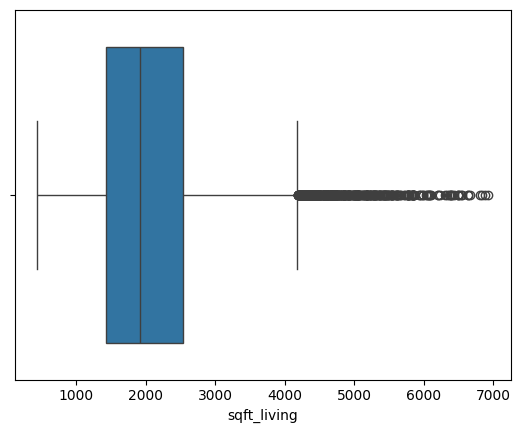

In [13]:
sns.boxplot(x=newdf['sqft_living'])

<Axes: xlabel='sqft_above'>

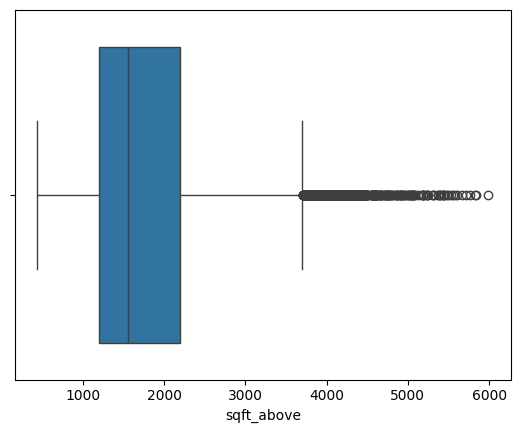

In [14]:
newdf=newdf[newdf['sqft_above']<6000]
sns.boxplot(x=newdf['sqft_above'])

### Checking Feature Skewness

Highly skewed numerical features can benefit from a logarithmic
transformation. Skewness is examined before applying transformations.

In [15]:
print(newdf.skew(numeric_only=True))

price             2.906009
bedrooms          0.181299
bathrooms         0.293480
sqft_living       1.080910
sqft_lot         13.330444
floors            0.613845
sqft_above        1.214840
sqft_basement     1.471906
yr_built         -0.479048
sqft_living15     1.064766
sqft_lot15        8.868501
dtype: float64


<h2>6.Feature Construction</h2>

In [16]:
newdf['total_sqft'] = newdf['sqft_above'] + newdf['sqft_basement']
newdf['house_age'] = 2015 - newdf['yr_built']
newdf['sqft_per_bedroom'] = newdf['sqft_living'] / newdf['bedrooms']
newdf['bath_per_bedroom'] = newdf['bathrooms'] / newdf['bedrooms']
print(newdf)
print(newdf.skew(numeric_only=True))

          price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0      221900.0         3       1.00         1180      5650     1.0   
1      538000.0         3       2.25         2570      7242     2.0   
2      180000.0         2       1.00          770     10000     1.0   
3      604000.0         4       3.00         1960      5000     1.0   
4      510000.0         3       2.00         1680      8080     1.0   
...         ...       ...        ...          ...       ...     ...   
21608  360000.0         3       2.50         1530      1131     3.0   
21609  400000.0         4       2.50         2310      5813     2.0   
21610  402101.0         2       0.75         1020      1350     2.0   
21611  400000.0         3       2.50         1600      2388     2.0   
21612  325000.0         2       0.75         1020      1076     2.0   

       sqft_above  sqft_basement  yr_built  sqft_living15  sqft_lot15  \
0            1180              0      1955           1340        5650   
1

<h2>7.TRAIN-TEST-SPLIT</h2>

In [17]:
x=newdf.drop('price',axis=1)
y=newdf['price']
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)
print(xtrain)

       bedrooms  bathrooms  sqft_living  sqft_lot  floors  sqft_above  \
443           3       1.50         1250    219978     1.0        1250   
11915         4       2.50         1640      6000     2.0        1640   
7028          3       2.50         2070     10908     2.0        2070   
14963         4       2.00         1890      4500     1.5        1490   
14294         3       2.50         2590     18980     1.0        2590   
...         ...        ...          ...       ...     ...         ...   
11622         4       1.75         1590      7920     2.0        1590   
12322         2       1.00          770      6542     1.0         770   
5563          3       2.50         1940      8547     1.0        1460   
880           3       1.50         1260      9570     1.0         870   
16254         3       1.75         1470      8350     1.0        1470   

       sqft_basement  yr_built  sqft_living15  sqft_lot15  total_sqft  \
443                0      1980           1930     

<H2>8.RIDGE REGRESSION WITH POLYNOMIAL FEATURES</H2>

In [18]:
poly=PolynomialFeatures(degree=2,include_bias=False)

logpro=ColumnTransformer(transformers=[
    ('trf1',FunctionTransformer(np.log1p),[2,3,5,6,8,9]),
],remainder='passthrough')

model1=Pipeline([
    ('log_transform',logpro),
    ('poly_transform',poly),
    ('scaler',StandardScaler()),
    ('ridge',RidgeCV(cv=5))
])

ytrainnew=np.log1p(ytrain)
ytestnew=np.log1p(ytest)

model1.fit(xtrain,ytrainnew)
yprednew1=model1.predict(xtest)
ytrainpred=model1.predict(xtrain)
ytest_actual=np.expm1(ytestnew)
ypredict_actual1=np.expm1(yprednew1)

print(ytest_actual)
print(ypredict_actual1)

9402     1090000.0
11134     220000.0
4901      350000.0
11799     365000.0
8382      288000.0
           ...    
20762     890000.0
5417      433000.0
4601      535000.0
9349      551870.0
11311     695000.0
Name: price, Length: 6309, dtype: float64
[939260.37237536 357144.36722021 333206.30273797 ... 398498.10609813
 453877.00431599 858484.40583375]


In [28]:
ridge_mae=mean_absolute_error(ytest_actual,ypredict_actual1)
ridge_mse=mean_squared_error(ytest_actual,ypredict_actual1)
ridge_r2=r2_score(ytest_actual,ypredict_actual1)
print("MAE is:",mean_absolute_error(ytest_actual,ypredict_actual1))
print("MSE is:",mean_squared_error(ytest_actual,ypredict_actual1))
print("R2 Score of Ridge Regression Model:",r2_score(ytest_actual,ypredict_actual1))

MAE is: 137526.22709397832
MSE is: 45979025756.06344
R2 Score of Ridge Regression Model: 0.6166353198408625


<h2>9.LINEAR REGRESSION</h2>

In [29]:
l=LinearRegression()
l.fit(xtrain,ytrain)
ypred2=l.predict(xtest)

linear_mae=mean_absolute_error(ytest,ypred2)
linear_mse=mean_squared_error(ytest,ypred2)
linear_r2=r2_score(ytest,ypred2)
print("MAE is:",mean_absolute_error(ytest,ypred2))
print("MSE is:",mean_squared_error(ytest,ypred2))
print("R2 Score of Linear Regression Model:",r2_score(ytest,ypred2))

MAE is: 153656.18383218985
MSE is: 52714552954.930756
R2 Score of Linear Regression Model: 0.5604757299444536


<h2>10.LASSO REGRESSION WITH POLYNOMIAL FEATURES</h2>

In [21]:
model2=Pipeline([
    ('logtranfomr',logpro),
    ('polytranfomr',poly),
    ('scaler',StandardScaler()),
    ('lrmodel',LassoCV(alphas=[0.01,0.1,1,10,100],cv=5,max_iter=100000))
])

model2.fit(xtrain,ytrainnew)
yprednew2=model2.predict(xtest)

ytest_actual=np.expm1(ytestnew)
ypredict_actual2=np.expm1(yprednew2)

print(ytest_actual)
print(ypredict_actual2)

9402     1090000.0
11134     220000.0
4901      350000.0
11799     365000.0
8382      288000.0
           ...    
20762     890000.0
5417      433000.0
4601      535000.0
9349      551870.0
11311     695000.0
Name: price, Length: 6309, dtype: float64
[857717.35019002 371011.58395362 361481.31520514 ... 349652.89710454
 430251.48405527 831657.38353673]


In [30]:
lasso_mae=mean_absolute_error(ytest_actual,ypredict_actual2)
lasso_mse=mean_squared_error(ytest_actual,ypredict_actual2)
lasso_r2=r2_score(ytest_actual,ypredict_actual2)
print("MAE is:",mean_absolute_error(ytest_actual,ypredict_actual2))
print("MSE is:",mean_squared_error(ytest_actual,ypredict_actual2))
print("R2 score of Lasso Regression Model is:",r2_score(ytest_actual,ypredict_actual2))

MAE is: 145996.8981765391
MSE is: 52151656634.42416
R2 score of Lasso Regression Model is: 0.5651690561801737


In [31]:
data = {
    'Linear Regression': {
        'MAE': linear_mae,
        'MSE': linear_mse,
        'R2 Score': linear_r2
    },
    'Ridge Regression': {
        'MAE': ridge_mae,
        'MSE': ridge_mse,
        'R2 Score': ridge_r2
    },
    'Lasso Regression': {
        'MAE': lasso_mae,
        'MSE': lasso_mse,
        'R2 Score': lasso_r2
    }
}

comparison = pd.DataFrame(data).T
comparison

,MAE,MSE,R2 Score
Linear Regression,153656.183832,5.271455e+10,0.560476
Ridge Regression,137526.227094,4.597903e+10,0.616635
Lasso Regression,145996.898177,5.215166e+10,0.565169
